In [1]:
# %env no_proxy='a.test.com,127.0.0.1,2.2.2.2'
!pip uninstall mindspore-gpu --y
!pip install mindspore==2.0.0

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/

[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [2]:
# Check the current MindSpore version.
!pip show mindspore

Name: mindspore
Version: 2.0.0
Summary: MindSpore is a new open source deep learning training/inference framework that could be used for mobile, edge and cloud scenarios.
Home-page: https://www.mindspore.cn
Author: The MindSpore Authors
Author-email: contact@mindspore.cn
License: Apache 2.0
Location: /home/ma-user/anaconda3/envs/MindSpore/lib/python3.7/site-packages
Requires: asttokens, astunparse, numpy, packaging, pillow, protobuf, psutil, scipy
Required-by: 


## Task 1: Augmenting data (110 points)

### Subtask 1: Set the environment (5 points)
**Requirements:**

a．Set the device to CPU or GPU.

In [3]:
import mindspore

# Question 1-1-1: Set the device you want to use.
mindspore.set_context(device_target='GPU')
print(mindspore.get_context(attr_key='device_target'))

GPU


In [4]:
 !pip install download 
from download import download
import os
# url = "https://obs-ai-3d23.obs.ap-southeast-1.myhuaweicloud.com/dataset.zip"
# ! wget -c https://mindspore-courses.obs.cn-north-4.myhuaweicloud.com/ICT/zhongyiyao/dataset.zip
# !unzip dataset.zip

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/

[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [5]:
# !wget https://kunpeng2026.obs.ap-southeast-3.myhuaweicloud.com/dataset20242025Reg.zip
# !unzip dataset20242025Reg.zip

#### **Data preprocessing**
The original image is quite large, with a size of 4 KB. You need to resize it to a specific size.

In [6]:
from PIL import Image
import numpy as np
data_dir = "/zhongyiyao/zhongyiyao"
new_data_path = "dataset1/zhongyiyao"
if not os.path.exists(new_data_path):
    for path in ['train','test']:
        data_path = data_dir + "/" + path
        classes = os.listdir(data_path)
        for (i,class_name) in enumerate(classes):
            floder_path =  data_path+"/"+class_name
            print(f"Processing{floder_path}...")
            for image_name in os.listdir(floder_path):
                try:
                    image = Image.open(floder_path + "/" + image_name)
                    image = image.resize((1000,1000))
                    target_dir = new_data_path+"/"+path+"/"+class_name
                    if not os.path.exists(target_dir):
                        os.makedirs(target_dir)
                    if not os.path.exists(target_dir+"/"+image_name):
                        image.save(target_dir+"/"+image_name)
                except:
                    pass     

#### **Dataset splitting**


In [7]:
from sklearn.model_selection import train_test_split
import shutil

def split_data(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """
    This function splits the data into training, validation, and test sets.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size/(1-test_size), random_state=random_state)

    return X_train, X_val, X_test, y_train, y_val, y_test


data_dir = "dataset1/zhongyiyao"
floders = os.listdir(data_dir)
target = ['train','test','valid']
if set(floders) == set(target):\
    pass
elif 'train' in floders:
    floders = os.listdir(data_dir)
    new_data_dir = os.path.join(data_dir,'train')
    classes = os.listdir(new_data_dir)
    if '.ipynb_checkpoints' in classes:
        classes.remove('.ipynb_checkpoints')
    imgs = []
    labels = []
    for (i,class_name) in enumerate(classes):
        new_path =  new_data_dir+"/"+class_name
        for image_name in os.listdir(new_path):
            imgs.append(image_name)
            labels.append(class_name)
    imgs_train,imgs_val,labels_train,labels_val = X_train, X_test, y_train, y_test = train_test_split(imgs, labels, test_size=0.2, random_state=42)
    print("Number of images in the training set:",len(imgs_train))
    print("Number of images in the validation set:",len(imgs_val))
    target_data_dir = os.path.join(data_dir,'valid')
    if not os.path.exists(target_data_dir):
        os.mkdir(target_data_dir)
    for (img,label) in zip(imgs_val,labels_val):
        source_path = os.path.join(data_dir,'train',label)
        target_path = os.path.join(data_dir,'valid',label)
        if not os.path.exists(target_path):
            os.mkdir(target_path)
        source_img = os.path.join(source_path,img)
        target_img = os.path.join(target_path,img)
        shutil.move(source_img,target_img)
else:
    phones = os.listdir(data_dir)
    imgs = []
    labels = []
    for phone in phones:
        phone_data_dir = os.path.join(data_dir,phone)
        yaowu_list = os.listdir(phone_data_dir)
        for yaowu in yaowu_list:
            yaowu_data_dir = os.path.join(phone_data_dir,yaowu)
            chengdu_list = os.listdir(yaowu_data_dir)
            for chengdu in chengdu_list:
                chengdu_data_dir = os.path.join(yaowu_data_dir,chengdu)
                for img in os.listdir(chengdu_data_dir):
                    imgs.append(img)
                    label = ' '.join([phone,yaowu,chengdu])
                    labels.append(label)
    imgs_train, imgs_val, imgs_test, labels_train, labels_val, labels_test = split_data(imgs, labels, test_size=0.2, val_size=0.2, random_state=42)
    img_label_tuple_list = [(imgs_train,labels_train),(imgs_val,labels_val),(imgs_test,labels_test)]
    for (i,split) in enumerate(spilits):
        target_data_dir = os.path.join(data_dir,split)
        if not os.path.exists(target_data_dir):
            os.mkdir(target_data_dir)
        imgs_list,labels_list = img_label_tuple_list[i]
        for (img,label) in zip(imgs_list,labels_list):
            label_split = label.split(' ')
            source_img = os.path.join(data_dir,label_split[0],label_split[1],label_split[2],img)
            target_img_dir = os.path.join(target_data_dir,label_split[1]+"_"+label_split[2])
            if not os.path.exists(target_img_dir):
                os.mkdir(target_img_dir)
            target_img = os.path.join(target_img_dir,img)
            shutil.move(source_img,target_img)
    

### Subtask 2: Augment data (65 points)
**Requirements:**
a.	Supplement code based on remarks. Specifically:
1. Use the GeneratorDataset API to convert data into a dataset.
2. Define a policy to crop the dataset.
3. Define channel transformation operations to convert the input image shape from <H, W, C> to <C, H, W>.
4. Define the output dataset size.

In [8]:
from mindspore.dataset import GeneratorDataset
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms
from mindspore import dtype as mstype

class Iterable:
    def __init__(self,data_path):
        self._data = []
        self._label = []
        self._error_list = []
        if data_path.endswith(('JPG','jpg','png','PNG')):
            image = Image.open(data_path)
            self._data.append(image)
            self._label.append(0)
        else:
            classes = os.listdir(data_path)
            if '.ipynb_checkpoints' in classes:
                classes.remove('.ipynb_checkpoints')
            for (i,class_name) in enumerate(classes):
                new_path =  data_path+"/"+class_name
                for image_name in os.listdir(new_path):
                    try:
                        image = Image.open(new_path + "/" + image_name)
                        self._data.append(image)
                        self._label.append(i)
                    except:
                        pass
                

    def __getitem__(self, index):
        return self._data[index], self._label[index]

    def __len__(self):
        return len(self._data)
    
    def get_error_list(self,):
        return self._error_list
    
def create_dataset_zhongyao(dataset_dir,usage,resize,batch_size,workers):
    data = Iterable(dataset_dir)
    # Question 1-2-1: Use the GeneratorDataset API to convert data into a dataset.
    data_set = GeneratorDataset(source=data, column_names=['image', 'label'])
    trans = []
    # Question 1-2-2: Define a policy to crop the dataset.
    # RandomCrop:
    # 1.size (Union[int, Sequence[int]]) - Image output size. Set it to 700;
    # 2.padding (Union[int, Sequence[int]], optional) - Number of pixels to pad on each edge of the image. Set it to a tuple with four integers, each having a value of 4.
    # RandomHorizontalFlip:
    # 1.prob (float, optional) - Image rotation probability. Set it to 0.5.
    if usage == "train":
        trans += [
            vision.RandomCrop(size=700, padding=(4, 4, 4, 4)),
            vision.RandomHorizontalFlip(prob=0.5)
        ]

    trans += [
        vision.Resize((resize,resize)),
        vision.Rescale(1.0 / 255.0, 0.0),
        vision.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]),
        # Question 1-2-3: Define channel transformation operations to convert the input image shape from <H, W, C> to <C, H, W>.
        vision.HWC2CHW()
    ]

    target_trans = transforms.TypeCast(mstype.int32)
    data_set = data_set.map(
        operations=trans,
        input_columns='image',
        num_parallel_workers=workers)

    data_set = data_set.map(
        operations=target_trans,
        input_columns='label',
        num_parallel_workers=workers)

    data_set = data_set.batch(batch_size,drop_remainder=True)

    return data_set

#### **Loading data**
Load the dataset in a defined mode.

In [9]:
import mindspore as ms
import random
data_dir = "dataset1/zhongyiyao"
train_dir = data_dir+"/"+"train"
valid_dir = data_dir+"/"+"valid"
test_dir = data_dir+"/"+"test"
batch_size = 32
image_size = 224
workers = 4
num_classes = 12

seed = 42
ms.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Question 1-2-4: Define the output dataset size.
dataset_train = create_dataset_zhongyao(dataset_dir=train_dir,
                                       usage="train",
                                       resize=image_size,
                                       batch_size=batch_size,
                                       workers=workers)
step_size_train = dataset_train.get_dataset_size() # Number of batches returned

dataset_val = create_dataset_zhongyao(dataset_dir=valid_dir,
                                     usage="valid",
                                     resize=image_size,
                                     batch_size=batch_size,
                                     workers=workers)
dataset_test = create_dataset_zhongyao(dataset_dir=test_dir,
                                     usage="test",
                                     resize=image_size,
                                     batch_size=batch_size,
                                     workers=workers)
step_size_val = dataset_val.get_dataset_size()   # Number of batches returned

print(f'training set data:{step_size_train*batch_size}\n')
print(f'evaluation set data:{step_size_val*batch_size}\n')

training set data:4384

evaluation set data:1088



#### **Label description**

- ph-sp: Cattail pollen-Raw
- ph_bj: Cattail pollen-Underprocessed
- ph_sz: Cattail pollen-Properly processed
- ph_tg: Cattail pollen-Overprocessed
- sz_sp: Hawthorn-Raw
- sz_bj: Hawthorn-Underprocessed
- sz_sz: Hawthorn-Properly processed
- sz_tg: Hawthorn-Overprocessed
- wblx_sp: Cowherb seed-Raw
- wblx_bj: Cowherb seed-Underprocessed
- wblx_sz: Cowherb seed-Properly processed
- wblx_tg: Cowherb seed-Overprocessed

In [10]:
index_label_dict = {}
classes = os.listdir(train_dir)
if '.ipynb_checkpoints' in classes:
    classes.remove('.ipynb_checkpoints')
for i,label in enumerate(classes):
    index_label_dict[i] = label
label2chin = {'ph_sp':'Cattail pollen-Raw',  'ph_bj':'Cattail pollen-Underprocessed', 'ph_sz':'Cattail pollen-Properly processed', 'ph_tg':'Cattail pollen-Overprocessed', 'sz_sp':'Hawthorn-Raw',
              'sz_bj':'Hawthorn-Underprocessed', 'sz_sz':'Hawthorn-Properly processed', 'sz_tg':'Hawthorn-Overprocessed', 'wblx_sp':'Cowherb seed-Raw', 'wblx_bj':'Cowherb seed-Underprocessed',
              'wblx_sz':'Cowherb seed-Properly processed', 'wblx_tg':'Cowherb seed-Overprocessed'}
index_label_dict

{0: 'sz_sz',
 1: 'sz_bj',
 2: 'sz_sp',
 3: 'sz_tg',
 4: 'ph_sp',
 5: 'wblx_sz',
 6: 'ph_tg',
 7: 'wblx_bj',
 8: 'ph_sz',
 9: 'wblx_tg',
 10: 'ph_bj',
 11: 'wblx_sp'}

### Subtask 3: Visualize data (40 points)
**Requirements:**

a.	Supplement code based on remarks. Specifically:

1. Use the create_dict_iterator API to create a data iterator and print a label list.

2. Use the transpose API to move the channel dimension to the end: CHW -> HWC.

3. Denormalization: Use std and mean to perform denormalization on image_trans.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Question 1-3-1: Use the create_dict_iterator API to create a data iterator and print a label list.
data_iter = next(dataset_train.create_dict_iterator())

images = data_iter["image"].asnumpy()
labels = data_iter["label"].asnumpy()
print(f"Image shape: {images.shape}, Label: {labels}")


Image shape: (32, 3, 224, 224), Label: [11  4  2  1  9  2  6  7  4 10 11  3  5  5 11  9  5 11 11  3 10  7 11  3
  6  3  1  3  5  6  4  3]


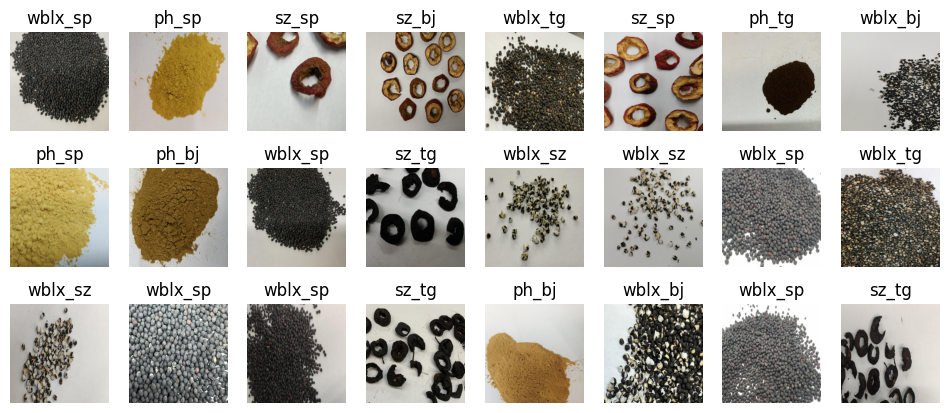

In [12]:
plt.figure(figsize=(12, 5))
for i in range(24):
    plt.subplot(3, 8, i+1)
    # Question 1-3-2: Use the transpose API to move the channel dimension to the end: CHW -> HWC
    image_trans = np.transpose(images[i], (1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    # Question 1-3-3: Denormalization: Use std and mean to perform denormalization on image_trans.
    image_trans = std * image_trans + mean
    image_trans = np.clip(image_trans, 0, 1)
    plt.title(index_label_dict[labels[i]])
    plt.imshow(image_trans)
    plt.axis("off")
plt.show()

## Task 2: Building a model (80 points)

### Subtask 1: Define a model class (60 points)
**Requirements:**
a. Supplement code based on remarks. Specifically:

1. Define a convolutional layer and a ReLU activation function.
2. Implement the residual connection of the ResidualBlockBase and ResidualBlock modules, and complete settings in self.layer4.

In [13]:
from mindspore import Model
from mindspore import context
import mindspore.ops as ops
from mindspore import Tensor, nn, set_context, GRAPH_MODE, train
from mindspore import load_checkpoint, load_param_into_net
from typing import Type, Union, List, Optional
from mindspore import nn, train
from mindspore.common.initializer import Normal


weight_init = Normal(mean=0, sigma=0.02)
gamma_init = Normal(mean=1, sigma=0.02)

class ResidualBlockBase(nn.Cell):
    expansion: int = 1

    def __init__(self, in_channel: int, out_channel: int,
                 stride: int = 1, norm: Optional[nn.Cell] = None,
                 down_sample: Optional[nn.Cell] = None) -> None:
        super(ResidualBlockBase, self).__init__()
        if not norm:
            self.norm = nn.BatchNorm2d(out_channel)
        else:
            self.norm = norm
        # Question 2-1-1: Define a convolutional layer and a ReLU activation function.
        # 1. Conv2d: 
        #    in_channels (int) - Spatial dimension of the tensor input to the Conv2d layer
        #    out_channels (int) - Spatial dimension of the tensor output from the Conv2d layer
        #    kernel_size (Union[int, tuple[int]]) - Height and width of a two-dimensional convolution kernel (3 x 3);
        #    stride (Union[int, tuple[int]]，optional) - Stride of a two-dimensional convolution kernel
        self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels=out_channel,
                               kernel_size=3, stride=stride,
                               weight_init=weight_init)
        self.conv2 = nn.Conv2d(in_channel, out_channel,
                               kernel_size=3, weight_init=weight_init)
        # 2. ReLU：To apply the Rectified Linear Unit (ReLU) for each element, use MindSpore APIs.
        self.relu = nn.ReLU()
        self.down_sample = down_sample

    def construct(self, x):
        """ResidualBlockBase construct."""
        identity = x

        out = self.conv1(x)
        out = self.norm(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.norm(out)

        if self.down_sample is not None:
            identity = self.down_sample(x)
        # Question 2-1-2: 
        # 1. Implement the residual connection of the ResidualBlockBase module.
        out = out + identity  # The output is the sum of the main branch and shortcuts.
        out = self.relu(out)

        return out


In [14]:
class ResidualBlock(nn.Cell):
    expansion = 4

    def __init__(self, in_channel: int, out_channel: int,
                 stride: int = 1, down_sample: Optional[nn.Cell] = None) -> None:
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channel, out_channel,
                               kernel_size=1, weight_init=weight_init)
        self.norm1 = nn.BatchNorm2d(out_channel)
        self.conv2 = nn.Conv2d(out_channel, out_channel,
                               kernel_size=3, stride=stride,
                               weight_init=weight_init)
        self.norm2 = nn.BatchNorm2d(out_channel)
        self.conv3 = nn.Conv2d(out_channel, out_channel * self.expansion,
                               kernel_size=1, weight_init=weight_init)
        self.norm3 = nn.BatchNorm2d(out_channel * self.expansion)

        self.relu = nn.ReLU()
        self.down_sample = down_sample

    def construct(self, x):

        identity = x

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.norm2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.norm3(out)

        if self.down_sample is not None:
            identity = self.down_sample(x)
        # 2. Implement the residual connection of the ResidualBlock module.
        out = out + identity  # The output is the sum of the main branch and shortcuts.
        out = self.relu(out)

        return out

In [15]:
def make_layer(last_out_channel, block: Type[Union[ResidualBlockBase, ResidualBlock]],
               channel: int, block_nums: int, stride: int = 1):
    down_sample = None


    if stride != 1 or last_out_channel != channel * block.expansion:

        down_sample = nn.SequentialCell([
            nn.Conv2d(last_out_channel, channel * block.expansion,
                      kernel_size=1, stride=stride, weight_init=weight_init),
            nn.BatchNorm2d(channel * block.expansion, gamma_init=gamma_init)
        ])

    layers = []
    layers.append(block(last_out_channel, channel, stride=stride, down_sample=down_sample))

    in_channel = channel * block.expansion

    for _ in range(1, block_nums):

        layers.append(block(in_channel, channel))

    return nn.SequentialCell(layers)

In [16]:
from mindspore import load_checkpoint, load_param_into_net
from mindspore import ops


class ResNet(nn.Cell):
    def __init__(self, block: Type[Union[ResidualBlockBase, ResidualBlock]],
                 layer_nums: List[int], num_classes: int, input_channel: int) -> None:
        super(ResNet, self).__init__()

        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, weight_init=weight_init)
        self.norm = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, pad_mode='same')
        self.layer1 = make_layer(64, block, 64, layer_nums[0])
        self.layer2 = make_layer(64 * block.expansion, block, 128, layer_nums[1], stride=2)
        self.layer3 = make_layer(128 * block.expansion, block, 256, layer_nums[2], stride=2)
        self.layer4 = make_layer(256 * block.expansion, block, 512, layer_nums[3], stride=2)
        self.avg_pool = ops.ReduceMean(keep_dims=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Dense(in_channels=input_channel, out_channels=num_classes)

    def construct(self, x):
        
        x = self.conv1(x)
        x = self.norm(x)
        x = self.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x,(2,3))
        
        x = self.flatten(x)
        x = self.fc(x)

        return x

In [17]:
def _resnet(block: Type[Union[ResidualBlockBase, ResidualBlock]],
            layers: List[int], num_classes: int, pretrained: bool, pretrained_ckpt: str,
            input_channel: int):
    model = ResNet(block, layers, num_classes, input_channel)
    return model


def resnet50(num_classes: int = 1000, pretrained: bool = False):
    resnet50_ckpt = "./LoadPretrainedModel/resnet50_224_new.ckpt"
    return _resnet(ResidualBlock, [3, 4, 6, 3], num_classes,
                   pretrained, resnet50_ckpt, 2048)


### Subtask 2: Initialize the model (20 points)
**Requirements:**

a. Instantiate the defined ResNet-50 model.


In [18]:
# Question 2-2-1: Instantiate the defined ResNet-50 model.
network = resnet50(num_classes=1000, pretrained=False)
num_class = 12
in_channel = network.fc.in_channels
fc = nn.Dense(in_channels=in_channel, out_channels=num_class)
network.fc = fc

for param in network.get_parameters():
    param.requires_grad = True


## Task 3: Training the model (130 points)

### Subtask 1: Train the model (90 points)
**Requirements:**
a. Supplement code based on remarks. Specifically:
1. Use the Momentum optimizer.
2. Use SoftmaxCrossEntropyWithLogits as the loss function, with parameters sparse=True and reduction='mean'.
3. Build your model: Use functional programming to calculate the loss, and then return the loss and the predicted values as logits.
4. Define the backpropagation function using the value_and_grad API.
5. Switch the model to the prediction mode.

In [19]:
num_epochs = 3
patience = 5
lr = nn.cosine_decay_lr(min_lr=0.00001, max_lr=0.001, total_step=step_size_train * num_epochs,
                        step_per_epoch=step_size_train, decay_epoch=num_epochs)
# Question 3-1-1: Use the Momentum optimizer and set the momentum factor to 0.9.
opt = nn.Momentum(params=network.trainable_params(), learning_rate=lr, momentum=0.9)
# Question 3-1-2: Use SoftmaxCrossEntropyWithLogits as the loss function, with parameters sparse=True and reduction='mean'.
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
model = ms.Model(network, loss_fn, opt, metrics={'acc'})

best_acc = 0
best_ckpt_dir = "./BestCheckpoint"
best_ckpt_path = "./BestCheckpoint/resnet50-best.ckpt"

#### **Defining training and inference functions**

In [20]:
def train_loop(model, dataset, loss_fn, optimizer):
    # Question 3-1-3: Build your model: Use functional programming to calculate the loss, and then return the loss and the predicted values as logits.
    def forward_fn(data, label):
        logits = model(data)
        loss = loss_fn(logits, label)
        return loss, logits

    # Question 3-1-4: Use the value_and_grad API to define the backpropagation function.
    grad_fn = ms.ops.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=True)

    def train_step(data, label):
        (loss, _), grads = grad_fn(data, label)
        loss = ops.depend(loss, optimizer(grads))
        return loss
    size = dataset.get_dataset_size()
    model.set_train()
    for batch, (data, label) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step(data, label)

        if batch % 100 == 0 or batch == step_size_train - 1:
            loss, current = loss.asnumpy(), batch
            print(f"loss: {loss:>7f}  [{current:>3d}/{size:>3d}]")

from sklearn.metrics import classification_report

def test_loop(model, dataset, loss_fn):
    num_batches = dataset.get_dataset_size()
    # Question 3-1-5: Set the model to the prediction mode.
    model.set_train(False)
    total, test_loss, correct = 0, 0, 0
    y_true = []
    y_pred = []
    for data, label in dataset.create_tuple_iterator():
        y_true.extend(label.asnumpy().tolist())
        pred = model(data)
        total += len(data)
        test_loss += loss_fn(pred, label).asnumpy()
        y_pred.extend(pred.argmax(1).asnumpy().tolist())
        correct += (pred.argmax(1) == label).asnumpy().sum()
    test_loss /= num_batches
    correct /= total
    print(f"Test: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    print(classification_report(y_true,y_pred,target_names= list(index_label_dict.values()),digits=3))
    return correct,test_loss


### Subtask 2: Save the model (40 points)
**Requirements:**

a. Save the weights after training to the path specified in the code.

1. Set conditions to obtain the best model weights during training.
2. Use the save_checkpoint API to save the model.
3. Train the model. (Take a screenshot of results.)

In [21]:
no_improvement_count = 0
acc_list = []
loss_list = []
stop_epoch = num_epochs
# for t in range(num_epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train_loop(network, dataset_train, loss_fn, opt)
#     acc,loss = test_loop(network, dataset_val, loss_fn)
#     acc_list.append(acc)
#     loss_list.append(loss)
#     # Question 3-2-1: Set conditions to obtain the best model weights during training based on the acc metric.
#     if acc > best_acc:
#         best_acc = acc
#         if not os.path.exists(best_ckpt_dir):
#             os.mkdir(best_ckpt_dir)
#         # Question 3-2-2: Use the save_checkpoint API to save the model in best_ckpt_path.
#         ms.save_checkpoint(network, best_ckpt_path)
#         no_improvement_count = 0
#     else:
#         no_improvement_count += 1
#         if no_improvement_count > patience:
#             print('Early stopping triggered. Restoring best weights...')
#             stop_epoch = t
#             break 
# print("Done!")


#### **Visualizing results**

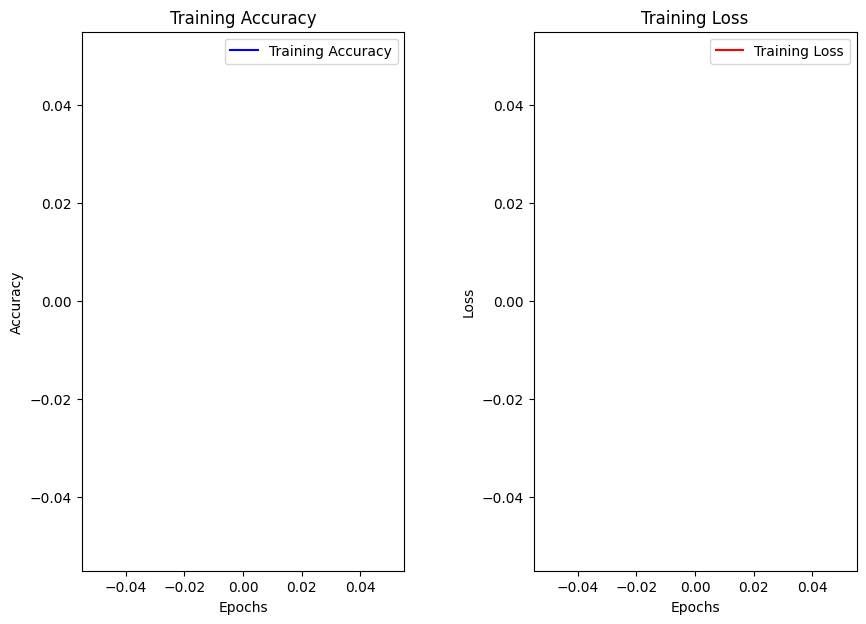

In [22]:
import matplotlib.pyplot as plt

def plot_training_process(acc_list, loss_list):
    epochs = range(1, len(acc_list) + 1)
    plt.figure(figsize=(10, 7))
    plt.subplot(121)
    plt.plot(epochs, acc_list, 'b-', label='Training Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Draw the loss function curve.
    plt.subplot(122)
    plt.plot(epochs, loss_list, 'r-', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplots_adjust(wspace=0.4)

    plt.show()

plot_training_process(acc_list, loss_list)


### Task 4: Evaluating the model (70 points)

#### Subtask 1: Perform model prediction (40 points)）
**Requirements:**
a. Supplement code based on remarks. Specifically:
1. Instantiate the ResNet-50 prediction model.
2. Load model parameters.
3. Load the test set data for evaluation.
4. Predict the image class.

#### **Loading the model**
Load the best weights of the trained model.

In [23]:
import matplotlib.pyplot as plt

num_class = 12  # 
# Question 4-1-1: Instantiate the ResNet-50 prediction model.
net = resnet50(num_classes=num_class, pretrained=False)
best_ckpt_path = 'BestCheckpoint/resnet50-best.ckpt'
# Question 4-1-2: Load model parameters.
param_dict = ms.load_checkpoint(best_ckpt_path)
ms.load_param_into_net(net, param_dict)
model = ms.Model(net)
image_size = 224
workers = 1

In [24]:
# # Question 4-1-3: Load the test set data for evaluation (complete code).
# # Requirement: Output the acc metric on the test set.
# acc = test_loop(net, dataset_test, loss_fn)
# print(f'Test set accuracy: {acc}')

#### **Inputting the image path for inference**
Input the path of one image for inference.

In [25]:
def predict_one(input_img):
    dataset_one = create_dataset_zhongyao(dataset_dir=input_img,
                                       usage="test",
                                       resize=image_size,
                                       batch_size=1,
                                       workers=workers)
    data = next(dataset_one.create_tuple_iterator())
    images = data[0].asnumpy()
    labels = data[1].asnumpy()
    # Question 4-1-4: Use the predict API to predict the image class.
    output = model.predict(ms.Tensor(images))
    pred = output.argmax(axis=1).asnumpy()
    return index_label_dict[pred[0]]

In [26]:
# input_img = "dataset1/zhongyiyao/train/sz_tg/IMG_3660.JPG"
# print(predict_one(input_img))

### Subtask 2: Infer the image class (30 points)
**Requirements:**
a. Supplement code based on remarks. Specifically:
1. Load the test set data for evaluation.
2. Infer the image class.
3. Display the images and their predicted values.

In [27]:
def visualize_model(dataset_test):
    # Question 4-2-1: Load the test set data (images and labels) for evaluation.
    data = next(dataset_test.create_tuple_iterator())
    images = data[0].asnumpy()
    labels = data[1].asnumpy()
    # Question 4-2-2: Infer the image class.
    output = model.predict(ms.Tensor(data[0]))
    pred = output.argmax(axis=1).asnumpy()

    plt.figure(figsize=(10, 6))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        color = 'blue' if pred[i] == labels[i] else 'red'
        plt.title('predict:{}  actual:{}'.format(index_label_dict[pred[i]],index_label_dict[labels[i]]), color=color)
        picture_show = np.transpose(images[i], (1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        picture_show = std * picture_show + mean
        picture_show = np.clip(picture_show, 0, 1)
        plt.imshow(picture_show)
        plt.axis('off')

    plt.show()


In [28]:
# # Question 4-2-3: Display the image and its predicted value. To do so, call the visualize_model function to display the inference data.
# visualize_model(dataset_test)

### Task 5: Optimizing the model (10 points)
### Subtask 1: Optimize the model (10 points)
**Requirements:**
a. Adjust the hyperparameters to ensure the model's accuracy on the test set is at least 5% higher than the results obtained in question 4-1-3 prior to hyperparameter adjustment.

Epoch 1
-------------------------------
loss: 2.695679  [  0/ 68]
Test: 
 Accuracy: 56.6%, Avg loss: 1.273329 

              precision    recall  f1-score   support

       sz_sz      1.000     0.114     0.205       105
       sz_bj      0.311     0.283     0.296        99
       sz_sp      0.543     0.937     0.687        95
       sz_tg      0.971     0.606     0.746       109
       ph_sp      0.303     1.000     0.465        66
     wblx_sz      0.467     0.887     0.612        80
       ph_tg      0.929     0.453     0.609        86
     wblx_bj      0.802     0.951     0.870       102
       ph_sz      0.873     0.552     0.676        87
     wblx_tg      0.710     0.431     0.537       102
       ph_bj      0.000     0.000     0.000        74
     wblx_sp      0.538     0.675     0.599        83

    accuracy                          0.566      1088
   macro avg      0.620     0.574     0.525      1088
weighted avg      0.648     0.566     0.534      1088



/home/ma-user/anaconda3/envs/MindSpore/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 2
-------------------------------
loss: 0.766800  [  0/ 68]
Test: 
 Accuracy: 42.9%, Avg loss: 2.736031 

              precision    recall  f1-score   support

       sz_sz      0.860     0.410     0.555       105
       sz_bj      1.000     0.071     0.132        99
       sz_sp      0.517     0.968     0.674        95
       sz_tg      0.359     0.477     0.409       109
       ph_sp      0.402     1.000     0.574        66
     wblx_sz      1.000     0.475     0.644        80
       ph_tg      0.223     0.430     0.294        86
     wblx_bj      0.385     1.000     0.556       102
       ph_sz      1.000     0.023     0.045        87
     wblx_tg      1.000     0.029     0.057       102
       ph_bj      0.000     0.000     0.000        74
     wblx_sp      0.373     0.301     0.333        83

    accuracy                          0.429      1088
   macro avg      0.593     0.432     0.356      1088
weighted avg      0.609     0.429     0.357      1088

Epoch 3
-------------

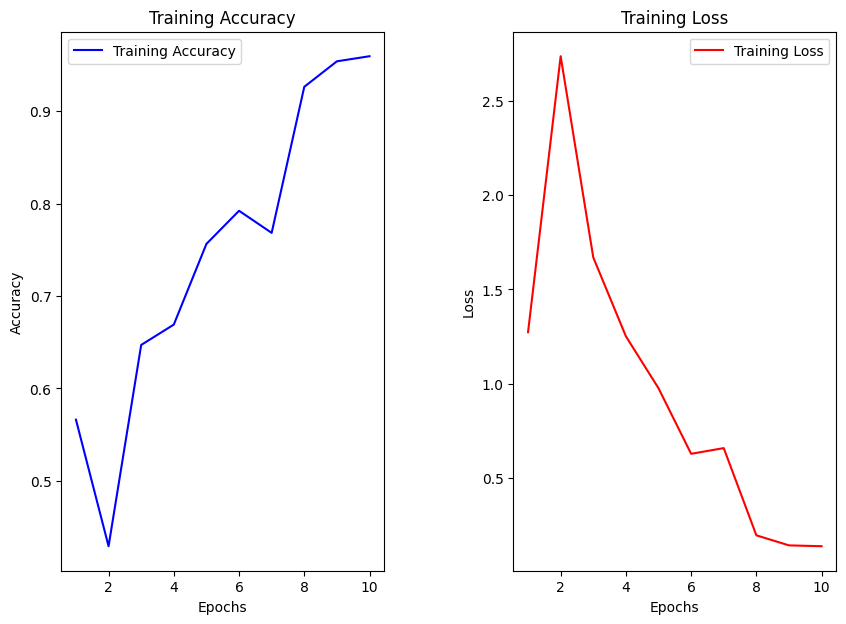

--- Optimized Model Test Set Evaluation ---
Test: 
 Accuracy: 94.6%, Avg loss: 0.171631 

              precision    recall  f1-score   support

       sz_sz      0.978     0.917     0.946        48
       sz_bj      0.907     1.000     0.951        49
       sz_sp      1.000     0.898     0.946        49
       sz_tg      0.906     1.000     0.950        48
       ph_sp      0.962     1.000     0.980        50
     wblx_sz      0.923     1.000     0.960        48
       ph_tg      0.920     1.000     0.958        46
     wblx_bj      0.815     1.000     0.898        44
       ph_sz      1.000     0.920     0.958        50
     wblx_tg      1.000     0.958     0.979        48
       ph_bj      1.000     0.959     0.979        49
     wblx_sp      1.000     0.702     0.825        47

    accuracy                          0.946       576
   macro avg      0.951     0.946     0.944       576
weighted avg      0.952     0.946     0.945       576



(0.9461805555555556, 0.17163095706039005)

In [29]:
# Task 5: Optimizing the model
# Strategy: increase epochs, tune learning rate, add weight decay, and use a stronger augmentation

num_epochs_opt = 10        # More epochs for better convergence
batch_size_opt = 64        # Larger batch for more stable gradients
image_size_opt = 224
workers_opt = 4

# Reload datasets with new batch size
dataset_train_opt = create_dataset_zhongyao(dataset_dir=train_dir, usage='train',
                                             resize=image_size_opt, batch_size=batch_size_opt,
                                             workers=workers_opt)
dataset_val_opt   = create_dataset_zhongyao(dataset_dir=valid_dir, usage='valid',
                                             resize=image_size_opt, batch_size=batch_size_opt,
                                             workers=workers_opt)
dataset_test_opt  = create_dataset_zhongyao(dataset_dir=test_dir,  usage='test',
                                             resize=image_size_opt, batch_size=batch_size_opt,
                                             workers=workers_opt)

step_size_train_opt = dataset_train_opt.get_dataset_size()

# Cosine LR schedule with higher max_lr for faster learning
lr_opt = nn.cosine_decay_lr(min_lr=1e-5, max_lr=0.01,
                            total_step=step_size_train_opt * num_epochs_opt,
                            step_per_epoch=step_size_train_opt,
                            decay_epoch=num_epochs_opt)

# Re-instantiate fresh model
network_opt = resnet50(num_classes=1000, pretrained=False)
network_opt.fc = nn.Dense(in_channels=network_opt.fc.in_channels, out_channels=num_classes)
for param in network_opt.get_parameters():
    param.requires_grad = True

# Momentum optimizer with weight_decay for regularization
opt_opt = nn.Momentum(params=network_opt.trainable_params(),
                      learning_rate=lr_opt,
                      momentum=0.9,
                      weight_decay=1e-4)   # L2 regularization to reduce overfitting

loss_fn_opt = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

best_acc_opt = 0
best_ckpt_opt_path = './BestCheckpoint/resnet50-best-optimized.ckpt'
no_improvement_count_opt = 0
patience_opt = 5
acc_list_opt = []
loss_list_opt = []

for t in range(num_epochs_opt):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(network_opt, dataset_train_opt, loss_fn_opt, opt_opt)
    acc, loss = test_loop(network_opt, dataset_val_opt, loss_fn_opt)
    acc_list_opt.append(acc)
    loss_list_opt.append(loss)
    if acc > best_acc_opt:
        best_acc_opt = acc
        if not os.path.exists(best_ckpt_dir):
            os.mkdir(best_ckpt_dir)
        ms.save_checkpoint(network_opt, best_ckpt_opt_path)
        no_improvement_count_opt = 0
    else:
        no_improvement_count_opt += 1
        if no_improvement_count_opt > patience_opt:
            print('Early stopping triggered.')
            break

print('Optimized training done!')
plot_training_process(acc_list_opt, loss_list_opt)

# Evaluate optimized model on test set
net_opt = resnet50(num_classes=num_classes, pretrained=False)
param_dict_opt = ms.load_checkpoint(best_ckpt_opt_path)
ms.load_param_into_net(net_opt, param_dict_opt)
print('--- Optimized Model Test Set Evaluation ---')
test_loop(net_opt, dataset_test_opt, loss_fn_opt)
